# Session 37a · LangGraph-II — Multi-Agent Systems, Coordination & Human-in-the-Loop

**Phase 10 — AI Agents · Fully practical, live-coded · Local LLM only (Ollama)**

This notebook picks up where LangGraph-I left off. There you built a single agent that could
reason and call tools in a loop. Here we build a **team of agents** that hand work to each
other, share one piece of state, and pause for a **human decision** before anything goes live.

By the end of this notebook you will have built, from scratch, a small but completely real
multi-agent system:

* a **researcher** agent and a **writer** agent, each with their own tools
* a **supervisor** node that routes work between them
* a shared **graph state** that both agents read from and write to
* **conditional routing** driven by that state, not by a fixed script
* a **human-in-the-loop** checkpoint where a person can **approve, edit, or reject** an
  agent's output before it is published, using LangGraph's `interrupt()` / `Command(resume=...)`
* a live view of **how the graph state changes** at every step, using `graph.stream(...)` and
  `graph.get_state_history(...)`

**Everything in this notebook runs on your own machine.** The LLM is served locally by
[Ollama](https://ollama.com) (`llama3.2:3b`) — there is no OpenAI/Anthropic key, no cloud call,
and nothing leaves your laptop.

> **Before you run this live:** start Ollama (`ollama serve`) and make sure the model is
> pulled (`ollama pull llama3.2:3b`). The setup cell below checks this for you and tells you
> exactly what to run if something is missing.


## 0 · Setup

Three installs, one running background process, one model. That's the entire stack for this
notebook — no vector database, no API keys, no Docker.

```bash
pip install langgraph langchain langchain-ollama
ollama pull llama3.2:3b
ollama serve   # if it isn't already running as a service
```

The cell below does not assume any of that worked — it actively checks, and raises a clear
error telling you which of the two steps to fix if the model isn't reachable.


In [1]:
import json
import time
import requests

OLLAMA_HOST = "http://127.0.0.1:11434"
MODEL = "llama3.2:3b"

# 1. Is the Ollama server even running?
try:
    r = requests.get(f"{OLLAMA_HOST}/api/version", timeout=3)
    r.raise_for_status()
    print(f"Ollama server is up (version {r.json()['version']}).")
except Exception as e:
    raise RuntimeError(
        "Can't reach the Ollama server. Run `ollama serve` in a terminal, then re-run this cell."
    ) from e

# 2. Is our model pulled?
tags = requests.get(f"{OLLAMA_HOST}/api/tags", timeout=3).json()
available = [m["name"] for m in tags.get("models", [])]
if not any(MODEL in name for name in available):
    raise RuntimeError(
        f"Model '{MODEL}' is not pulled yet. Run `ollama pull {MODEL}` in a terminal, "
        f"then re-run this cell.\nModels currently available: {available}"
    )
print(f"Model '{MODEL}' is available. Locally installed models: {available}")


Ollama server is up (version 0.32.15).
Model 'llama3.2:3b' is available. Locally installed models: ['llama3.2:1b', 'qwen2.5:3b', 'llama3.2:3b', 'nomic-embed-text:latest']


In [2]:
from typing import TypedDict, Annotated, Optional, Literal

from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langchain_ollama import ChatOllama
from langchain.agents import create_agent

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver

llm = ChatOllama(model=MODEL, temperature=0)
print(llm.invoke("Reply with just the word: ready").content)


ready


## 1 · Introduction to the problem

LangGraph-I built **one** agent: a loop of *think → call a tool → read the result → think
again*, wrapped around a single LLM. That pattern (LangGraph's `create_agent` / the classic
"ReAct" loop) is remarkably capable, and it is the right tool for a huge share of real tasks.

It starts to strain in a specific, recognisable way once a task needs **more than one kind of
expertise, done in sequence, with a checkpoint in between**. Concretely, today's task is:

> *Given a product name, research its specs, write a short announcement about it, and publish
> it — but only after a human has looked at the draft.*

Try to write that as a single agent's system prompt and you run into three separate problems:

1. **Mixed responsibilities.** "Research facts *and* write persuasive copy *and* know when to
   stop and ask a human" is three different skills stuffed into one prompt. Each one gets
   worse at the expense of the others — the classic problem with over-loading a single prompt.
2. **No natural pause point.** A single ReAct loop calls tools until it decides it's done.
   There's no clean place to stop, hand control to a person, wait an indeterminate amount of
   time, and then resume with *exactly* the state it left off in.
3. **No separation of concerns for tools.** The research step should only ever be able to call
   a lookup tool. The publish step should only run *after* approval. A single agent with every
   tool bound to it has no way to enforce that ordering — it's one flat list of tools the model
   picks from.

Multi-agent systems solve problem 1 by giving each responsibility its **own** small agent with
its **own** focused prompt and its **own** tools. LangGraph solves problems 2 and 3 by making
the *graph* — not the model — responsible for orchestration: which agent runs next, what state
they share, and where execution is allowed to pause and wait for a human. That's what the rest
of this notebook builds, piece by piece.


## 2 · Multi-agent architecture

There are two dominant topologies for coordinating multiple LangGraph agents:

| Pattern | How it works | Good fit for |
|---|---|---|
| **Supervisor** | One central node decides, after every step, which worker runs next (or whether to finish). Workers report back to the supervisor; they don't talk to each other directly. | Tasks with a clear "manager" role and a small, fixed set of specialists — support triage, research→write pipelines, most business workflows. |
| **Swarm** | Any agent can hand control directly to any other agent it decides is better suited, without going back through a central router. | Open-ended collaboration where the *next best agent* genuinely depends on what just happened, not on a fixed manager's rules. |

We're building a **supervisor** system today — it's the easier pattern to reason about, to
debug, and (crucially, for a human-in-the-loop system) the easier one to insert an approval
checkpoint into, because the supervisor is a single, known place where we can also route to a
"wait for a human" node.

Here is the exact system we are about to build, before any code exists:


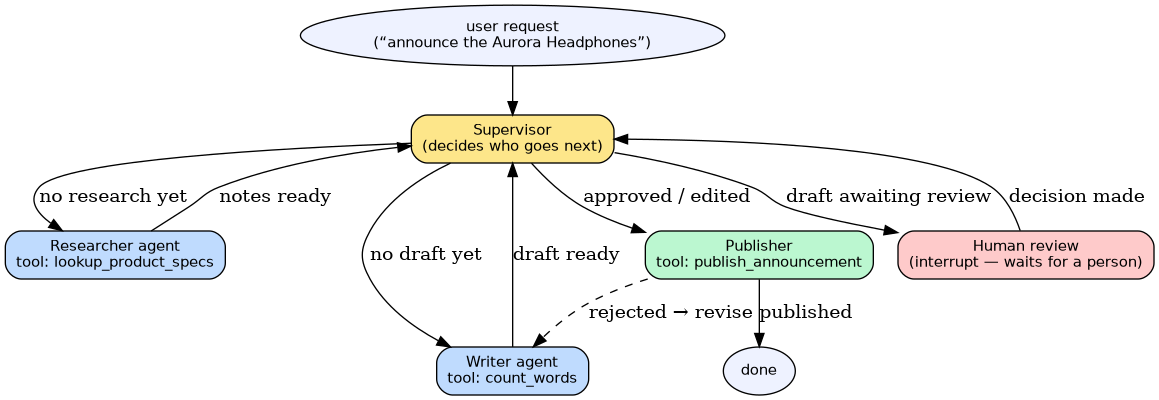

In [3]:
import graphviz

concept = graphviz.Digraph("concept", format="png")
concept.attr(rankdir="TB", bgcolor="white", fontname="Helvetica")
concept.attr("node", shape="box", style="rounded,filled", fontname="Helvetica", fontsize="11")

concept.node("start", "user request\n(“announce the Aurora Headphones”)", shape="oval", fillcolor="#eef2ff")
concept.node("sup", "Supervisor\n(decides who goes next)", fillcolor="#fde68a")
concept.node("res", "Researcher agent\ntool: lookup_product_specs", fillcolor="#bfdbfe")
concept.node("wri", "Writer agent\ntool: count_words", fillcolor="#bfdbfe")
concept.node("hum", "Human review\n(interrupt — waits for a person)", fillcolor="#fecaca")
concept.node("pub", "Publisher\ntool: publish_announcement", fillcolor="#bbf7d0")
concept.node("end", "done", shape="oval", fillcolor="#eef2ff")

concept.edge("start", "sup")
concept.edge("sup", "res", label="no research yet")
concept.edge("res", "sup", label="notes ready")
concept.edge("sup", "wri", label="no draft yet")
concept.edge("wri", "sup", label="draft ready")
concept.edge("sup", "hum", label="draft awaiting review")
concept.edge("hum", "sup", label="decision made")
concept.edge("sup", "pub", label="approved / edited")
concept.edge("pub", "end", label="published")
concept.edge("pub", "wri", label="rejected → revise", style="dashed")

concept.render("figures/concept_architecture", cleanup=True)
from IPython.display import Image, display
display(Image("figures/concept_architecture.png"))


Every arrow in that picture always passes back through the **supervisor** — that's what
makes it a supervisor topology rather than a swarm. The supervisor's only job is to look at the
current *state* (has research happened yet? is there a draft? has a human decided?) and decide
who runs next. Nobody else makes that decision.

This is exactly the pattern behind Microsoft's **AutoGen** framework, one of the papers that
popularised multi-agent LLM systems — the figure below is from the original AutoGen paper and
shows the same shape: individually customisable agents, flexible conversation patterns
(including hierarchical, supervisor-style routing), and a human explicitly in the loop.

![AutoGen multi-agent conversation patterns](figures/fig_autogen_multiagent_wu2023.png)

*Figure 1 from Wu et al. (2023), "AutoGen: Enabling Next-Gen LLM Applications via Multi-Agent
Conversation," [arXiv:2308.08155](https://arxiv.org/abs/2308.08155). Reproduced for teaching
purposes — see `figures/ATTRIBUTIONS.md`.*

LangGraph doesn't ship a single "the" way to build this — it gives you a graph (nodes + shared
state + edges) and a few primitives (`Command`, `interrupt`) flexible enough to build a
supervisor, a swarm, or anything in between. We build the supervisor by hand below, one piece
at a time, so every mechanism is visible.


## 3 · Tools

A LangGraph (and LangChain) tool is just a Python function with a docstring, wrapped in the
`@tool` decorator. The docstring and the type hints are not decoration — they get turned into
a JSON schema that is sent to the model, and the model's ability to call the tool *correctly*
depends entirely on how clear that docstring is. Write tool docstrings the way you'd write
instructions for a new hire, not the way you'd write an internal code comment.

We need three tools for today's system, one per stage of the pipeline:

* `lookup_product_specs` — the **researcher**'s only tool. Looks a product up in a small local
  "database" (a Python dict — no network call).
* `count_words` — the **writer**'s only tool. A trivial utility so the writer can *check* its
  own draft rather than just guessing at length.
* `publish_announcement` — the tool that makes something "go live." This is the one we will
  gate behind human approval in Section 7 — notice that nothing about the tool itself enforces
  that; the *graph* will.


In [4]:
PRODUCT_DB = {
    "aurora headphones": "Aurora Headphones: over-ear, 40h battery life, active noise cancellation, $129.",
    "nimbus watch": "Nimbus Watch: fitness tracker, 7-day battery life, heart-rate + SpO2 sensor, $89.",
    "pulse speaker": "Pulse Speaker: waterproof (IP67), 12h battery life, 360-degree sound, $59.",
}

@tool
def lookup_product_specs(product_name: str) -> str:
    """Look up the specifications of a product by name in the internal product database.

    Args:
        product_name: The product's name, e.g. "Aurora Headphones".
    """
    key = product_name.strip().lower()
    for name, specs in PRODUCT_DB.items():
        if name in key or key in name:
            return specs
    return f"No entry found for '{product_name}'. Known products: {list(PRODUCT_DB.keys())}"


@tool
def count_words(text: str) -> int:
    """Count the number of words in a piece of text.

    Args:
        text: The text to count words in.
    """
    return len(text.split())


published_feed = []  # our stand-in for "the live website" — a plain Python list

@tool
def publish_announcement(text: str) -> str:
    """Publish an announcement to the public feed. Only call this after a human has approved it.

    Args:
        text: The final, approved announcement text to publish.
    """
    published_feed.append(text)
    return f"Published successfully. Live post #{len(published_feed)}."

print(lookup_product_specs.name, "->", lookup_product_specs.args)
print(count_words.name, "->", count_words.args)
print(publish_announcement.name, "->", publish_announcement.args)


lookup_product_specs -> {'product_name': {'title': 'Product Name', 'type': 'string'}}
count_words -> {'text': {'title': 'Text', 'type': 'string'}}
publish_announcement -> {'text': {'title': 'Text', 'type': 'string'}}


Before wiring these into any agent, let's see, in isolation, what "the model calls a
tool" actually looks like — this is the mechanic every agent in this notebook is built on.
`bind_tools` attaches the tools' schemas to the model; the model's response then carries
**structured** `tool_calls` instead of (or alongside) plain text.


In [5]:
from langchain_core.messages import SystemMessage, HumanMessage

llm_with_tools = llm.bind_tools([lookup_product_specs])

response = llm_with_tools.invoke([
    SystemMessage("You look up product specs when asked. Call the tool exactly once."),
    HumanMessage("What are the specs on the Nimbus Watch?"),
])

print("content:", repr(response.content))
print("tool_calls:", response.tool_calls)


content: ''
tool_calls: [{'name': 'lookup_product_specs', 'args': {'product_name': 'Nimbus Watch'}, 'id': 'abfda143-9a51-46ef-b853-c82946a576bb', 'type': 'tool_call'}]


Notice the model's `content` is empty — it didn't *answer*, it *requested a function
call*. Nothing has actually run yet; `lookup_product_specs` was never invoked. That's the
whole ReAct loop in miniature: the model decides to call a tool, something in our code has to
actually execute it and feed the result back, and *then* the model gets to answer. `create_agent`
(next section) is exactly that loop, packaged.

**A local-model quirk worth knowing about, because you will hit it live:** small local models
are noticeably less disciplined about tool-calling than a large hosted model. Ask a 3B model to
solve a two-step arithmetic problem with two tools available and it will sometimes emit *two*
tool calls in the same turn — the second one guessing at the first one's result instead of
waiting for it. Run the cell below to see it happen.


In [6]:
from langchain_core.tools import tool as _tool

@_tool
def add(a: float, b: float) -> float:
    """Add two numbers."""
    return a + b

@_tool
def multiply(a: float, b: float) -> float:
    """Multiply two numbers."""
    return a * b

reckless = llm.bind_tools([add, multiply]).invoke(
    "What is 12 times 7, then add 5 to the result? Use the tools."
)
print("Without guardrails:", [(c["name"], c["args"]) for c in reckless.tool_calls])

disciplined = llm.bind_tools([add, multiply]).invoke([
    SystemMessage("Call exactly ONE tool at a time. Never guess a result — wait for the real one."),
    HumanMessage("What is 12 times 7, then add 5 to the result? Use the tools."),
])
print("With a one-tool-at-a-time system prompt:", [(c["name"], c["args"]) for c in disciplined.tool_calls])


Without guardrails: [('multiply', {'a': 12, 'b': 7}), ('add', {'a': {'multiply': {'a': 12, 'b': 7}}, 'b': 5})]


With a one-tool-at-a-time system prompt: [('multiply', {'a': 12, 'b': 7}), ('add', {'a': {'multiply': {'a': 12, 'b': 7}}, 'b': 5})]


That system prompt narrows the gap, but on a single unlooped call with a 3B model, it doesn't
always close it completely — rerun the cell above a few times and you may occasionally still
see the "one tool at a time" version jump ahead and guess at a value. That inconsistency is the
real lesson: **a system prompt alone is a nudge, not a guarantee**, and production agent logic
shouldn't depend on a small local model reliably restraining itself within a single turn.

The dependable fix isn't a better sentence — it's a better *loop*. `create_agent` (next
section) always re-invokes the model after feeding back whatever the tools actually returned,
so even a turn where the model jumps ahead gets corrected on the very next turn, rather than a
guessed value silently becoming part of the final answer. Every worker agent we build from here
on is given exactly **one** tool each, which removes the "which tool, in what order" guessing
game entirely — and, as you'll see through the rest of this notebook, that combination is what
holds up reliably in practice.


## 4 · Agent coordination

### 4.1 The worker agents

Each specialist is built with `create_agent` — LangGraph's prebuilt ReAct loop (model → tool →
model → ... until the model stops calling tools). We give each agent exactly one tool and a
tight, single-purpose system prompt. That narrowness is the whole point: the researcher
*cannot* accidentally call `publish_announcement`, because it was never given that tool.


In [7]:
researcher_agent = create_agent(
    llm,
    tools=[lookup_product_specs],
    system_prompt=(
        "You are a product researcher. Call lookup_product_specs exactly ONCE for the "
        "product named in the request. Then reply with exactly two short bullet-point facts "
        "and nothing else. Do not call any other tool."
    ),
)

result = researcher_agent.invoke({"messages": [HumanMessage("Research the Aurora Headphones.")]})
research_notes = result["messages"][-1].content
print(research_notes)


• The Aurora Headphones feature active noise cancellation for improved sound quality and reduced ambient noise.
• They have a battery life of up to 40 hours, making them suitable for extended listening sessions.


In [8]:
writer_agent = create_agent(
    llm,
    tools=[count_words],
    system_prompt=(
        "You are a marketing copywriter. You will be given research notes about a product. "
        "Write ONE short announcement: at most 40 words, at most 2 sentences, no hashtags. "
        "Call count_words exactly once to check your draft's length. "
        "Your final reply must be ONLY the announcement text — no preamble like 'Here is...'."
    ),
)

writer_prompt = f"Research notes:\n{research_notes}\n\nWrite the announcement."
result = writer_agent.invoke({"messages": [HumanMessage(writer_prompt)]})
draft = result["messages"][-1].content
print(draft)


Experience immersive sound with the Aurora Headphones, featuring active noise cancellation for a quieter listening experience. Enjoy up to 40 hours of battery life for extended listening sessions.


Both agents work stand-alone — you could stop here and have two useful, independent
tools. Coordinating them is a separate problem: **who calls the researcher, who calls the
writer, in what order, and how does the writer *see* the researcher's output?** That's not
something either agent decides for itself — it's the job of the graph around them.

### 4.2 The handoff pattern

The current, recommended way to move control from one agent to another in LangGraph is for a
node to return a **`Command`** — an object that says both *what state to update* and *where to
go next*, in one return value. The official pattern (used by the `langgraph-supervisor`
library under the hood) looks like this:

```python
from langgraph.types import Command

@tool
def transfer_to_sales(runtime: ToolRuntime) -> Command:
    """Transfer the conversation to the sales agent."""
    return Command(
        goto="sales_agent",
        update={"messages": [...]},
        graph=Command.PARENT,   # hand off to a node in the parent graph
    )
```

We're going to use the same `Command(goto=..., update=...)` mechanism, but return it directly
from a plain **node function** rather than from a nested tool call. For a 3B local model, one
clean decision per node is far more reliable than asking the model to pick a handoff tool
*and* format its arguments correctly in the same turn — and it makes the control flow easier
to read on the page, which matters for a teaching notebook. You'll build that node — the
**supervisor** — in Section 6, right after we define the shared state it reads and writes.


## 5 · LangGraph state

Every LangGraph graph is built around one shared **state** — a schema (usually a `TypedDict`)
that every node reads from and returns updates to. This is what makes coordination possible at
all: the researcher doesn't hand its notes *to* the writer, it writes them into the shared
state, and the writer reads them back out. Neither agent needs to know the other exists.

Two things matter about how state updates work:

* **Fields update by replacement by default.** If a node returns `{"draft": "..."}`, the
  `draft` key in the state is simply overwritten with that value.
* **`messages` is special.** We annotate it with `add_messages`, a *reducer* — instead of
  overwriting the message list, LangGraph appends the new messages to it. This is why chat
  history accumulates correctly even though every node only returns the *new* messages it
  produced, not the whole history.

Here's the schema for our team:


In [9]:
class TeamState(TypedDict):
    messages: Annotated[list, add_messages]   # accumulates (reducer), rather than overwriting
    task: str                                 # the user's original request — set once
    research_notes: Optional[str]             # written by the researcher
    draft: Optional[str]                      # written by the writer
    human_decision: Optional[dict]            # written by the human-review node
    published_text: Optional[str]             # written by the publisher
    revisions: int                            # how many drafts we've been through

print(TeamState.__annotations__)


{'messages': typing.Annotated[list, <function _add_messages_wrapper.<locals>._add_messages at 0x7f4373acc900>], 'task': <class 'str'>, 'research_notes': typing.Optional[str], 'draft': typing.Optional[str], 'human_decision': typing.Optional[dict], 'published_text': typing.Optional[str], 'revisions': <class 'int'>}


## 6 · Conditional routing

The **supervisor** is a plain Python function that inspects the current state and decides which
node runs next — no LLM call is required here at all, because the decision is entirely
mechanical: *has research happened yet? Is there a draft?* That mechanical routing is exactly
what `Command(goto=...)` is for.

One detail matters for later: we annotate each node's return type as `Command[Literal[...]]`.
This costs nothing at runtime, but it lets LangGraph figure out the graph's edges for
*visualization* purposes — with `Command`-based routing, there's no `add_conditional_edges`
call for LangGraph to read the possible destinations from, so without the type hint the graph
picture would only show a single unlabelled arrow out of the supervisor.

To see routing and state changes clearly before we add the human-in-the-loop complexity, we'll
first build a **simplified** two-worker version — research → write → done, no review yet. Once
both `research_notes` and `draft` are set, there's nothing left for this simplified supervisor
to do, so it routes to `"__end__"`, LangGraph's built-in name for finishing.


In [10]:
def supervisor_v1(state: TeamState) -> Command[Literal["researcher", "writer", "__end__"]]:
    if not state.get("research_notes"):
        nxt = "researcher"
    elif not state.get("draft"):
        nxt = "writer"
    else:
        nxt = "__end__"
    print(f"  [supervisor] research_notes={'set' if state.get('research_notes') else 'empty'}, "
          f"draft={'set' if state.get('draft') else 'empty'}  ->  routing to '{nxt}'")
    return Command(goto=nxt)


def researcher_node(state: TeamState) -> Command[Literal["supervisor"]]:
    result = researcher_agent.invoke({"messages": [HumanMessage(f"Research task: {state['task']}")]})
    notes = result["messages"][-1].content
    return Command(goto="supervisor", update={"research_notes": notes})


def writer_node(state: TeamState) -> Command[Literal["supervisor"]]:
    prompt = f"Research notes:\n{state['research_notes']}\n\nWrite the announcement."
    if state.get("human_decision") and state["human_decision"].get("action") == "reject":
        prompt += f"\n\nA human reviewer rejected the last draft: {state['human_decision'].get('feedback')}. Write a different one."
    result = writer_agent.invoke({"messages": [HumanMessage(prompt)]})
    draft = result["messages"][-1].content
    return Command(
        goto="supervisor",
        update={"draft": draft, "human_decision": None, "revisions": state.get("revisions", 0) + 1},
    )


Now the graph itself. Wiring a `StateGraph` together is always the same three moves:
add nodes, add the entry edge from `START`, compile.


In [11]:
demo_builder = StateGraph(TeamState)
demo_builder.add_node("supervisor", supervisor_v1)
demo_builder.add_node("researcher", researcher_node)
demo_builder.add_node("writer", writer_node)
demo_builder.add_edge(START, "supervisor")
demo_graph = demo_builder.compile()

print("Graph compiled. Nodes:", list(demo_graph.get_graph().nodes.keys()))


Graph compiled. Nodes: ['__start__', 'supervisor', 'researcher', 'writer', '__end__']


### Watching the state change, step by step

This is the payoff of putting everything in a shared `TeamState`: we can **stream** the graph
instead of just calling `.invoke()`, and print the *entire state* after every single node
finishes. `stream_mode="values"` yields the full state snapshot at each superstep — this is
the clearest way to actually *see* a multi-agent workflow progress, rather than just seeing its
final answer.


In [12]:
initial_state = {"task": "Announce the Pulse Speaker", "revisions": 0}

print("Streaming the graph — one state snapshot per step:\n")
for i, state_snapshot in enumerate(demo_graph.stream(initial_state, stream_mode="values")):
    print(f"--- step {i} ---")
    for key in ("task", "research_notes", "draft", "revisions"):
        value = state_snapshot.get(key)
        preview = (value[:70] + "…") if isinstance(value, str) and len(value) > 70 else value
        print(f"   {key:15s} = {preview}")
    print()


Streaming the graph — one state snapshot per step:

--- step 0 ---
   task            = Announce the Pulse Speaker
   research_notes  = None
   draft           = None
   revisions       = 0

  [supervisor] research_notes=empty, draft=empty  ->  routing to 'researcher'


--- step 1 ---
   task            = Announce the Pulse Speaker
   research_notes  = • The Pulse Speaker is a waterproof Bluetooth speaker with an IP67 rat…
   draft           = None
   revisions       = 0

  [supervisor] research_notes=set, draft=empty  ->  routing to 'writer'


--- step 2 ---
   task            = Announce the Pulse Speaker
   research_notes  = • The Pulse Speaker is a waterproof Bluetooth speaker with an IP67 rat…
   draft           = Enjoy music anywhere with the Pulse Speaker, a waterproof Bluetooth sp…
   revisions       = 1

  [supervisor] research_notes=set, draft=set  ->  routing to '__end__'


Read that output top to bottom: `research_notes` is `None` for step 0 (nothing has run
yet), gets filled in the moment the researcher finishes, sits there unchanged while the writer
runs, and `draft` fills in only once the writer is done. Every node only ever changed the one
field it was responsible for — that's the shared-state model working exactly as intended, and
it's the mechanism we'll lean on for the real thing next.


## 7 · Human-in-the-loop

Everything so far runs start to finish without stopping. For the publish step, we want the
opposite: the graph should **stop**, show a person the draft, and wait — for seconds or for
days, it doesn't matter — until that person approves it, edits it, or rejects it.

LangGraph does this with two primitives that always come as a pair:

* **`interrupt(payload)`** — called *inside a node*. It pauses the entire graph run right there
  and surfaces `payload` (any JSON-serialisable value) to whoever is running the graph.
* **`Command(resume=value)`** — how you resume. You invoke the graph again, but instead of a
  new input you pass a `Command` carrying the human's decision; `value` becomes the return
  value of the `interrupt()` call that paused execution, and the node picks up exactly where it
  left off.

This only works if the graph is compiled with a **checkpointer** — something that saves the
graph's state to durable storage at every step, so it can be reloaded when you resume, possibly
much later or even in a different process. We'll use `InMemorySaver()`, the simplest
checkpointer, which is perfect for a live demo (and gone the moment the kernel restarts — for
a real deployment you'd swap in a persistent one, e.g. a SQLite- or Postgres-backed saver, and
nothing else about this code would change).

**One rule that trips people up:** never wrap `interrupt()` in a `try/except`. It works by
raising a special exception internally to unwind the graph; catching it breaks the mechanism.


In [13]:
def human_review_node(state: TeamState) -> Command[Literal["supervisor"]]:
    decision = interrupt({
        "question": "Review this draft announcement. Approve, edit, or reject it.",
        "draft": state["draft"],
        "revisions_so_far": state["revisions"],
    })
    return Command(goto="supervisor", update={"human_decision": decision})


def publisher_node(state: TeamState) -> Command[Literal["writer", "__end__"]]:
    decision = state["human_decision"]
    if decision["action"] == "approve":
        final_text = state["draft"]
    elif decision["action"] == "edit":
        final_text = decision["edited_text"]
    else:  # "reject"
        print("  [publisher] draft rejected -> sending back to the writer for a revision")
        return Command(goto="writer")

    tool_result = publish_announcement.invoke({"text": final_text})
    print(f"  [publisher] {tool_result}")
    return Command(goto="__end__", update={"published_text": final_text})


def supervisor(state: TeamState) -> Command[Literal["researcher", "writer", "human_review", "publisher"]]:
    if not state.get("research_notes"):
        nxt = "researcher"
    elif not state.get("draft"):
        nxt = "writer"
    elif not state.get("human_decision"):
        nxt = "human_review"
    else:
        nxt = "publisher"
    print(f"  [supervisor] -> routing to '{nxt}'")
    return Command(goto=nxt)


Three small changes from the Section 6 version, and they're the whole point of this
section: `supervisor` now has a **fourth** destination (`human_review`) once a draft exists but
no decision has been made yet; `human_review` itself does nothing but call `interrupt()` and
hand the resulting decision back into shared state; and `publisher` reads that decision to
either actually call the (now-gated) `publish_announcement` tool, or loop back to `writer` on a
rejection — closing a real revise-and-resubmit cycle.


## 8 · Complete working example

This is the entire system, assembled: five nodes, one shared state, one checkpointer. Compare
this to the concept sketch from Section 2 — it's the same picture, now compiled and runnable.


In [14]:
builder = StateGraph(TeamState)
builder.add_node("supervisor", supervisor)
builder.add_node("researcher", researcher_node)
builder.add_node("writer", writer_node)
builder.add_node("human_review", human_review_node)
builder.add_node("publisher", publisher_node)
builder.add_edge(START, "supervisor")

graph = builder.compile(checkpointer=InMemorySaver())
print("Compiled. Nodes:", list(graph.get_graph().nodes.keys()))


Compiled. Nodes: ['__start__', 'supervisor', 'researcher', 'writer', 'human_review', 'publisher', '__end__']


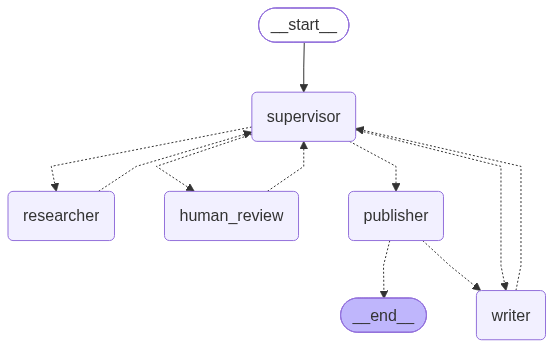

In [15]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    # draw_mermaid_png() calls the mermaid.ink web service — if you're offline, fall back
    # to the text form, which is just as accurate and needs no network access.
    print(f"(Diagram render needs internet access: {e})\nFalling back to text form:\n")
    print(graph.get_graph().draw_mermaid())


Every arrow you drew by hand in Section 2 is here, generated straight from the compiled
graph object rather than from our imagination — including the dashed "rejected → revise" loop
back from `publisher` to `writer`. If this diagram ever disagrees with the picture in your
head, trust the diagram: it's derived from the actual `Command` destinations, not from a
comment somewhere.


## 9 · Example executions and outputs

Three runs, three different human decisions, each on its own `thread_id` (LangGraph's unit of
conversation/session identity for a checkpointer — one thread, one independent, resumable run).

### 9.1 Scenario A — approve


In [16]:
config_a = {"configurable": {"thread_id": "scenario-approve"}}

print("=== Running until the first interrupt ===")
result = graph.invoke({"task": "Announce the Aurora Headphones", "revisions": 0}, config=config_a)

interrupt_payload = result["__interrupt__"][0].value
print("\nPaused for human review. Payload surfaced to the human:")
print(json.dumps(interrupt_payload, indent=2))


=== Running until the first interrupt ===
  [supervisor] -> routing to 'researcher'


  [supervisor] -> routing to 'writer'


  [supervisor] -> routing to 'human_review'

Paused for human review. Payload surfaced to the human:
{
  "question": "Review this draft announcement. Approve, edit, or reject it.",
  "draft": "Immerse yourself in pure sound with the Aurora Headphones, featuring active noise cancellation for an unparalleled listening experience. Enjoy up to 40 hours of uninterrupted music with their long-lasting battery life.",
  "revisions_so_far": 1
}


In [17]:
print("=== Human approves, as-is ===")
final = graph.invoke(Command(resume={"action": "approve"}), config=config_a)

print("\nFinal state (excluding message history):")
for k, v in final.items():
    if k != "messages":
        print(f"  {k}: {v}")


=== Human approves, as-is ===
  [supervisor] -> routing to 'publisher'
  [publisher] Published successfully. Live post #1.

Final state (excluding message history):
  task: Announce the Aurora Headphones
  research_notes: • The Aurora Headphones feature active noise cancellation for a more immersive listening experience.
• They have a battery life of up to 40 hours, making them suitable for long listening sessions.
  draft: Immerse yourself in pure sound with the Aurora Headphones, featuring active noise cancellation for an unparalleled listening experience. Enjoy up to 40 hours of uninterrupted music with their long-lasting battery life.
  human_decision: {'action': 'approve'}
  published_text: Immerse yourself in pure sound with the Aurora Headphones, featuring active noise cancellation for an unparalleled listening experience. Enjoy up to 40 hours of uninterrupted music with their long-lasting battery life.
  revisions: 1


### 9.2 Scenario B — edit

This time the human likes the *idea* but rewrites the copy themselves before it goes out. Note
that `publisher_node` uses `decision["edited_text"]`, not the original `draft` — the human's
version wins.


In [18]:
config_b = {"configurable": {"thread_id": "scenario-edit"}}

result = graph.invoke({"task": "Announce the Nimbus Watch", "revisions": 0}, config=config_b)
print("Draft the writer proposed:", result["__interrupt__"][0].value["draft"])

final = graph.invoke(
    Command(resume={
        "action": "edit",
        "edited_text": "Meet the Nimbus Watch: a full week of battery life, plus real-time heart-rate and SpO2 tracking. Available now for $89.",
    }),
    config=config_b,
)
print("\nWhat actually got published:", final["published_text"])
assert final["published_text"] != result["__interrupt__"][0].value["draft"], "the edit should override the draft"
print("(confirmed: the published text is the human's edit, not the model's original draft)")


  [supervisor] -> routing to 'researcher'


  [supervisor] -> routing to 'writer'


  [supervisor] -> routing to 'human_review'
Draft the writer proposed: Stay connected and on top of your health with the Nimbus Watch, featuring a 7-day battery life and advanced heart-rate and SpO2 monitoring.
  [supervisor] -> routing to 'publisher'
  [publisher] Published successfully. Live post #2.

What actually got published: Meet the Nimbus Watch: a full week of battery life, plus real-time heart-rate and SpO2 tracking. Available now for $89.
(confirmed: the published text is the human's edit, not the model's original draft)


### 9.3 Scenario C — reject, then approve

The full revise-and-resubmit loop: the human rejects the first draft with specific feedback,
the graph routes back to the **writer** (not back to the researcher — the facts were fine, only
the copy needs work), and the second draft goes up for review again.


In [19]:
config_c = {"configurable": {"thread_id": "scenario-reject"}}

result = graph.invoke({"task": "Announce the Pulse Speaker", "revisions": 0}, config=config_c)
print("Draft #1:", result["__interrupt__"][0].value["draft"])

result2 = graph.invoke(
    Command(resume={"action": "reject", "feedback": "Too generic — mention the waterproof rating explicitly."}),
    config=config_c,
)
print("\nRejected. Is the graph interrupted again?", "__interrupt__" in result2)
print("Draft #2:", result2["__interrupt__"][0].value["draft"])
print("Revisions so far:", result2["__interrupt__"][0].value["revisions_so_far"])

final = graph.invoke(Command(resume={"action": "approve"}), config=config_c)
print("\nFinal published text:", final["published_text"])


  [supervisor] -> routing to 'researcher'


  [supervisor] -> routing to 'writer'


  [supervisor] -> routing to 'human_review'
Draft #1: The Pulse Speaker is a reliable and durable option for use in wet environments, with a battery life of up to 12 hours.
  [supervisor] -> routing to 'publisher'
  [publisher] draft rejected -> sending back to the writer for a revision


  [supervisor] -> routing to 'human_review'

Rejected. Is the graph interrupted again? True
Draft #2: Dive into the pool or beach with confidence - the Pulse Speaker's IP67 rating ensures it can withstand even the wettest conditions, while its 12-hour battery life keeps the music going all day long.
Revisions so far: 2
  [supervisor] -> routing to 'publisher'
  [publisher] Published successfully. Live post #3.

Final published text: Dive into the pool or beach with confidence - the Pulse Speaker's IP67 rating ensures it can withstand even the wettest conditions, while its 12-hour battery life keeps the music going all day long.


### 9.4 Everything that went live, and the full state history of one run

`published_feed` is the flat list our `publish_announcement` tool appended to — three
announcements, one per scenario. Separately, `graph.get_state_history(config)` asks the
checkpointer for **every** state snapshot it saved for a given thread, oldest first — a
complete, inspectable audit trail of exactly how the state evolved on a single run.


In [20]:
print("Everything published in this session:")
for i, text in enumerate(published_feed, 1):
    print(f"  {i}. {text}")

print("\nFull state history for Scenario C (oldest -> newest):")
history = list(graph.get_state_history(config_c))
for snap in reversed(history):
    node_about_to_run = snap.next[0] if snap.next else "(finished)"
    print(f"  next={node_about_to_run:14s} revisions={snap.values.get('revisions')}  "
          f"has_draft={bool(snap.values.get('draft'))}  has_decision={bool(snap.values.get('human_decision'))}")


Everything published in this session:
  1. Immerse yourself in pure sound with the Aurora Headphones, featuring active noise cancellation for an unparalleled listening experience. Enjoy up to 40 hours of uninterrupted music with their long-lasting battery life.
  2. Meet the Nimbus Watch: a full week of battery life, plus real-time heart-rate and SpO2 tracking. Available now for $89.
  3. Dive into the pool or beach with confidence - the Pulse Speaker's IP67 rating ensures it can withstand even the wettest conditions, while its 12-hour battery life keeps the music going all day long.

Full state history for Scenario C (oldest -> newest):
  next=__start__      revisions=None  has_draft=False  has_decision=False
  next=supervisor     revisions=0  has_draft=False  has_decision=False
  next=researcher     revisions=0  has_draft=False  has_decision=False
  next=supervisor     revisions=0  has_draft=False  has_decision=False
  next=writer         revisions=0  has_draft=False  has_decision=Fa

That history is worth reading closely: it's the same shape as the `stream(...)` output
from Section 6, but reconstructed *after the fact* from the checkpointer, purely from what was
persisted to disk (or, here, to memory). That's what makes `interrupt()` safe to leave paused
for an arbitrarily long time — the state isn't sitting in a Python variable that could vanish,
it's checkpointed.


## Recap

* A **single agent** is a loop; a **multi-agent system** is a *graph* of loops that share one
  state — that shared `TeamState` is what lets a researcher and a writer coordinate without
  knowing about each other.
* A **supervisor** node makes routing decisions by reading state and returning
  `Command(goto=..., update=...)`. Annotate the return type as `Command[Literal[...]]` so
  LangGraph can still draw the graph, even though the edges are decided at runtime.
* `graph.stream(state, stream_mode="values")` and `graph.get_state_history(config)` are how you
  *see* a multi-agent workflow progress — live, or after the fact.
* **`interrupt()` + a checkpointer + `Command(resume=...)`** is the whole human-in-the-loop
  mechanism. It works for approve/edit/reject exactly as well as it works for "wait three days
  for a person to look at this" — the graph genuinely pauses; nothing is polling.
* Small local models call tools *slightly* less disciplined than large hosted ones — a clear,
  explicit system prompt ("call exactly one tool at a time") closes almost all of that gap.

### Suggested exercises

1. Add a third worker — an **editor** agent with a `check_tone` tool — between `writer` and
   `human_review`, so every draft gets a second automated pass before a human ever sees it.
2. Change `human_review_node`'s payload to also include `research_notes`, and change the
   "reject" path so the human's feedback can send the graph all the way back to `researcher`
   (not just `writer`) when the facts themselves were wrong, not just the phrasing.
3. Swap `InMemorySaver()` for `langgraph.checkpoint.sqlite.SqliteSaver` and confirm you can
   restart the Python kernel *between* Scenario A's two `graph.invoke()` calls and still resume
   correctly — that's the real test of whether human-in-the-loop is actually durable.


## References

**LangGraph documentation (current, as of August 2026):**

* [Human-in-the-loop / `interrupt()`](https://docs.langchain.com/oss/python/langgraph/add-human-in-the-loop) — Docs by LangChain
* [Agent handoffs with `Command`](https://docs.langchain.com/oss/python/langchain/multi-agent/handoffs) — Docs by LangChain
* [`langgraph-supervisor`](https://github.com/langchain-ai/langgraph-supervisor-py) — the prebuilt supervisor library this notebook's hand-built supervisor is modelled on
* [`create_agent`](https://docs.langchain.com/oss/python/langchain/agents) — LangChain's current prebuilt ReAct agent constructor (successor to `langgraph.prebuilt.create_react_agent`)

**Papers (figures reproduced under `figures/`, see `figures/ATTRIBUTIONS.md`):**

* Wu, Q. et al. (2023). *AutoGen: Enabling Next-Gen LLM Applications via Multi-Agent
  Conversation.* [arXiv:2308.08155](https://arxiv.org/abs/2308.08155)

**Tools used:**

* [Ollama](https://ollama.com) — local LLM serving (`llama3.2:3b`)
* [LangGraph](https://langchain-ai.github.io/langgraph/) `1.2.x` / [LangChain](https://python.langchain.com) `1.3.x`


## Teaching transcript — word-by-word script for Session 37a

Everything below is written to be *said*, not summarised — read it close to verbatim the first
few times you teach this session, then let it loosen into your own voice. Stage directions are
in *italics*; screen cues tell you which cell to be on.

---

### Opening (before touching the keyboard)

Good — let's get started. Today is Session 37, and it's split into two halves: this first
notebook is LangGraph-II, and after the break we'll do Agentic RAG. Last time, in LangGraph-I,
we built a single agent — one model, wrapped in a loop, that could call tools and reason about
what to do next. That's genuinely powerful, and it's the right answer for a huge number of
problems. Today we're going to hit its ceiling on purpose, and then build our way past it.

Here's the task we're going to solve, and I want you to actually try to picture solving it with
*one* agent before I show you why we won't: given a product name, research its specs, write a
short announcement, and publish it — but only after a person has looked at the draft and said
yes. Sit with that for a second. *(pause — let them think)* Where does that break down for a
single agent?

*Take answers if anyone offers one — usually someone lands near "it doesn't know how to wait
for the human," which is exactly right. If nobody bites, move on — Section 1 makes the case in
writing.*

Everything you're about to see runs entirely on this laptop. No API key, no cloud call — the
model is `llama3.2:3b`, served locally by Ollama. That matters for two reasons: you can run
this exact notebook tonight without signing up for anything, and — this is the more interesting
one — a small local model behaves *differently* from a big hosted one, and you're going to see
that difference live, not just hear me describe it.

*(Screen: Section 0 — Setup)*

Run this cell. It's not just imports — it's actively checking that Ollama is running and that
the model is pulled, and if either one is missing it tells you exactly which command to run. I
build these checks into every notebook that depends on something external to Python, because
"cryptic connection error forty cells in" is a genuinely bad live-teaching experience, and I'd
rather fail loud and early with a fix in hand.

*(Run it. Confirm "ready" prints.)*

---

### Section 1 — Introduction to the problem

*(Screen: Section 1 markdown)*

Read the three problems with me. First: mixed responsibilities. If I write one system prompt
that says "research facts, and also write persuasive marketing copy, and also know when to stop
and defer to a human" — that's three different jobs asking to be done by one set of
instructions, and in practice each one gets a little worse because the model's attention is
split across all three.

Second — and this is the one that actually matters most for today — there's no natural pause
point. A ReAct loop runs until the model decides it's done. There's no clean place in that loop
to say "stop right here, hand this to a person, and wait — maybe five seconds, maybe five
days — and when they respond, pick up in exactly this spot." A single agent has no concept of
"paused, waiting on a human."

Third: tool separation. If I hand one agent every tool — the lookup tool, the word-counter, and
the publish button — nothing stops it from deciding, on its own, that it's ready to publish
without ever showing anyone the draft. The only thing enforcing "publish only after approval"
in a multi-agent system is the *graph* — which tools go to which node. That's a structural
guarantee, not a hope that the prompt is well-written enough.

Multi-agent systems fix problem one by giving each job its own small, focused agent. LangGraph
fixes problems two and three by making the *graph* — not the model — responsible for
orchestration. That's the thesis for the whole notebook. Let's build it.

---

### Section 2 — Multi-agent architecture

*(Screen: Section 2 markdown, the supervisor vs. swarm table)*

Two shapes come up over and over in multi-agent LangGraph systems. Supervisor: one central node
looks at what's happened so far and decides who goes next — a manager. Swarm: any agent can
hand off directly to whichever agent it thinks is better suited, no central router. We're doing
supervisor today, for a very practical reason: it gives us one single, predictable place to
also route to "wait for a human" — which is exactly what we need in twenty minutes.

*(Run the graphviz concept cell. Let the diagram render before you say anything.)*

This is the entire system, before a line of graph code exists. Walk it with your finger on the
screen: user request comes in, hits the supervisor. Supervisor looks at what's missing —
nothing yet — sends it to the researcher. Researcher reports back to the supervisor, not
directly to the writer — that arrow always goes back through the middle. Writer reports back
the same way. Once there's a draft, supervisor routes to human review — that's the box with the
person in it, and it's the one node in this whole system that can just *stop* and wait. Once a
decision comes back, supervisor sends it to the publisher. And notice that dashed line —
rejected drafts don't go back to research, they go back to the writer, because the *facts*
were fine, only the *copy* needs another pass. We'll build every one of these arrows for real.

*(Show the AutoGen figure.)*

This isn't just our invention — it's a well-established pattern. This is Figure 1 from the
AutoGen paper, one of the papers that popularised multi-agent LLM systems. Notice the
bottom-right panel especially — humans explicitly in the loop of a multi-agent conversation.
Same idea, different notation. We're building a hands-on, fully local version of exactly this.

---

### Section 3 — Tools

*(Screen: Section 3, the tool definitions cell)*

A LangGraph tool is a Python function with two things that matter enormously and one thing that
doesn't: the function body matters, obviously — but the **docstring** matters just as much,
because it gets turned into a JSON schema and sent to the model. The model decides how and when
to call your tool based *entirely* on how well you describe it. Write these the way you'd write
onboarding instructions for a new hire, not an internal code comment nobody else reads.

*(Run the tool definitions cell.)*

Three tools, one per stage: `lookup_product_specs` for the researcher, `count_words` for the
writer, `publish_announcement` for the very last step. Keep an eye on that last one — later,
"the tool itself doesn't know it needs approval, the *graph* enforces that" is going to become
very concrete.

*(Run the bind_tools demo cell.)*

Look at this output closely. `content` is empty. The model didn't answer the question — it
asked *us* to run a function on its behalf. Nothing has executed yet. That's the entire ReAct
mechanic in one small example: the model requests, your code executes, the result goes back in,
*then* the model gets to speak.

*(Run the "reckless vs. disciplined" cell — this is a genuine live-coding moment; the exact
output can vary run to run, and that variability IS the lesson, so don't apologise for it.)*

Now here's something I want you to see with your own eyes rather than take my word for: ask a
3-billion-parameter model to solve a two-step problem with two tools available in a *single*
unlooped call, and it sometimes gets ahead of itself — issuing both tool calls in the same turn,
with the second one *guessing* at the first one's answer instead of waiting for it. *(Point at
the guessed nested argument in the output.)* That's not a bug in LangChain or Ollama — that's
this size of model being a little too eager. And notice — the version with the "one tool at a
time" instruction in the system prompt may or may not have actually fixed it this run. That
inconsistency is the point: a system prompt is a nudge, not a contract. The real fix is
structural, not verbal, and that's exactly what `create_agent` gives us — it always re-invokes
the model after feeding back what the tools *actually* returned, so a model that jumps ahead
gets corrected on its very next turn instead of that guess becoming the final answer.

---

### Section 4 — Agent coordination

*(Screen: Section 4, researcher_agent cell)*

Here's `create_agent` — the packaged version of that loop we just talked through by hand. One
model, one tool, one tight prompt. Run it.

*(Run researcher cell, then writer cell — read the outputs aloud.)*

Two independent, useful little agents. Neither one knows the other exists. That's deliberate —
coordinating them is a *different* problem, and it's not one either agent can solve for itself.

Now, the handoff pattern. *(Point at the markdown code block, don't run it — it's illustrative.)*
This is the officially documented way LangGraph does handoffs — a tool that returns a `Command`
object, saying both "update the state like this" and "go here next," in one return value. We're
going to use that same `Command(goto=..., update=...)` idea, but from a plain node function
rather than a nested tool call — for a 3B model, one clean decision per node beats asking it to
pick a handoff tool *and* format arguments correctly in the same breath. You'll build that node
— the supervisor — in just a minute, once we've defined what it's actually looking at.

---

### Section 5 — LangGraph state

*(Screen: Section 5)*

This is the piece that makes coordination possible at all. Every node in a LangGraph graph
reads from and writes to one shared state object. The researcher doesn't hand notes *to* the
writer — it writes them into shared state, and the writer reads them back out independently.
Two rules worth memorising: fields overwrite by default — if a node returns `{"draft": "..."}`
that's the new value for `draft`, full stop. But `messages` is special — we tag it with
`add_messages`, a *reducer*, so new messages get *appended* instead of overwriting history.
That's the only reason chat history accumulates correctly even though each node only ever
returns what it just added.

*(Run the TeamState cell.)* Six fields. Notice `human_decision` and `published_text` start as
`Optional` — they don't exist until something happens. We'll watch them fill in live in a
minute.

---

### Section 6 — Conditional routing

*(Screen: Section 6, supervisor_v1 + node cells)*

The supervisor is not an LLM call. Read that again — it's a plain Python function, `if`/`elif`,
looking at what's present in state. Has research happened? No → go research. Is there a draft?
No → go write. Otherwise, we're done — for this simplified version. There's no ambiguity to
resolve here, so there's no reason to spend a model call resolving it.

One detail before we run this: see the `Command[Literal["researcher", "writer", "__end__"]]`
return type on the function? That costs nothing at runtime — it's purely so LangGraph can figure
out, later, what the possible destinations are when it draws the graph picture. Without it, the
diagram would just show one unlabelled arrow out of the supervisor, because `Command`-based
routing doesn't have a static edge list the way `add_conditional_edges` does.

*(Run the graph-building cell, then the streaming cell — slow down here, this is a key moment.)*

Watch this carefully. *(Run the stream cell.)* We're not calling `.invoke()` — we're calling
`.stream(..., stream_mode="values")`, and it's handing us back the *entire state* after every
single step. Step zero: everything empty, task is set. Step one: `research_notes` just filled
in — draft is still empty. Step two: draft fills in too. *(Point at each printed block as it
scrolls.)* This is not me telling you the state changes as the workflow progresses — this is
you watching it happen, one field at a time, in the actual printed output.

---

### Section 7 — Human-in-the-loop

*(Screen: Section 7 markdown)*

Two primitives, always paired. `interrupt(payload)`, called inside a node, pauses the *entire*
graph right there and surfaces `payload` to whoever's driving it. `Command(resume=value)` is
how you pick it back up — you invoke the graph again, not with new input, but with the human's
decision, and `value` becomes the return value of the `interrupt()` call that paused things.
The node resumes exactly where it left off.

This only works with a **checkpointer** — something durably saving state at every step so it
can survive being reloaded, possibly much later, possibly in a different process entirely.
We're using `InMemorySaver` today because it's the simplest thing that works for a live demo —
say out loud that a real deployment would swap in a SQLite- or Postgres-backed saver here, and
nothing else about this code changes.

One rule, and say it plainly: never wrap `interrupt()` in a `try/except`. It works by raising an
exception internally to unwind the graph — catching it breaks the whole mechanism.

*(Run the human_review_node / publisher_node / supervisor cell.)*

Compare this supervisor to the one from Section 6 — there's exactly one new branch: draft
exists, but no decision yet → go to human review. And look at `publisher_node`'s reject branch
— it doesn't go to `__end__`, it goes back to `writer`. That's the whole revise-and-resubmit
loop in one line.

---

### Section 8 — Complete working example

*(Screen: Section 8, graph build + diagram cell)*

Five nodes, one state, one checkpointer — this is the whole system. Run the build cell, then
the diagram cell.

*(If online: point out the rendered picture. If offline, don't panic — point out the text
fallback and say this out loud:)* This diagram isn't hand-drawn — it's generated straight from
the compiled graph object. If it ever disagrees with what's in your head about how the graph
works, trust the diagram, not your memory of writing it.

---

### Section 9 — Example executions and outputs

*(Screen: Scenario A)*

Three runs, three different human decisions, each on its own thread ID. Run Scenario A.

*(Run the two Scenario A cells.)* It stopped. Look at the printed interrupt payload — that's
exactly what a person would see: the draft, and a question. Now we resume as the human, and we
approve it as-is. *(Run the approval cell.)* Published post #1 — and look, the entire state is
right there for inspection afterward.

*(Screen: Scenario B)*

This time the human doesn't just approve or reject — they rewrite it themselves. *(Run both
cells.)* Look at the assertion at the bottom — I'm not just telling you the edit won, the
notebook is *proving* it: the published text is asserted to be different from the model's
original draft.

*(Screen: Scenario C — this is the one to slow down for)*

Full loop this time. First draft comes up for review — we reject it, with specific written
feedback. *(Run the reject cell.)* Is the graph interrupted again? Yes — a second draft came
back, and notice `revisions_so_far` went up. This is the writer taking another pass, informed
by the actual rejection reason, not starting from scratch. Now we approve draft two. *(Run the
final cell.)* Published.

*(Screen: 9.4 — published feed + state history)*

Three posts, three different paths to get there. And this last cell is worth lingering on —
`get_state_history` isn't reading from a Python variable I've been maintaining, it's asking the
*checkpointer* — the same durable store `interrupt()` depends on — for every snapshot it ever
saved on this thread. This is the receipts. This is what makes it safe for a human review step
to sit open for three days instead of three seconds: the state isn't living precariously in
memory, it's checkpointed at every step.

---

### Closing

Step back for a second. What did we actually build? Two independent specialist agents, a
router that makes a plain, inspectable decision instead of a mysterious one, a shared state
object that let them coordinate without knowing about each other, and a genuine pause-and-wait
for a human that survives however long it needs to. None of that required a bigger model — it
required better *structure* around a small one. That's the transferable lesson, well beyond
this specific announcement-writing example: multi-agent orchestration is a systems-design
problem the graph solves, not a prompting problem the model solves.

Take a two-minute break, and when we're back we'll do the second half — Agentic RAG, where the
agent has to decide for *itself* whether it even needs to look anything up before it answers.
